In [113]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
DATA_ROOT = Path(r"D:\\cells\\ML\\HEP2_png")

CLASS_NAMES = ["24", "48", "72", "control"]
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_IDX.items()}

IMG_SIZE = 512
BATCH_SIZE = 8
SEED = 42

USE_CACHE = True

AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(CLASS_TO_IDX)

{'24': 0, '48': 1, '72': 2, 'control': 3}


In [116]:
rows = []

for class_name in CLASS_NAMES:
    class_dir = DATA_ROOT / class_name

    if not class_dir.exists():
        raise FileNotFoundError(f"Не найдена папка класса: {class_dir}")

    image_paths = sorted(class_dir.glob("*.png"))

    if len(image_paths) == 0:
        raise RuntimeError(f"В папке {class_dir} нет PNG-изображений")

    for path in image_paths:
        rows.append({
            "path": str(path),
            "class": class_name,
            "label": CLASS_TO_IDX[class_name]
        })

df = pd.DataFrame(rows)

print("Всего изображений:", len(df))
df.head()

Всего изображений: 827


,path,class,label
0,D:\cells\ML\HEP2_png\24\TUC-20251219092727377.png,24,0
1,D:\cells\ML\HEP2_png\24\TUC-20251219092733486.png,24,0
2,D:\cells\ML\HEP2_png\24\TUC-20251219092737240.png,24,0
3,D:\cells\ML\HEP2_png\24\TUC-20251219092741404.png,24,0
4,D:\cells\ML\HEP2_png\24\TUC-20251219092745351.png,24,0


In [117]:
class_counts = (
    df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

print(class_counts)

class
24         269
48         128
72          86
control    344
Name: count, dtype: int32


In [118]:
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=df_temp["label"]
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("train:", len(df_train))
print("val:  ", len(df_val))
print("test: ", len(df_test))

train: 578
val:   124
test:  125


In [119]:
def show_split_distribution(name, split_df):
    counts = (
        split_df["class"]
        .value_counts()
        .reindex(CLASS_NAMES)
        .fillna(0)
        .astype(int)
    )

    print(f"\n{name}")
    print(counts)
    return counts


train_counts = show_split_distribution("TRAIN", df_train)
val_counts = show_split_distribution("VAL", df_val)
test_counts = show_split_distribution("TEST", df_test)


TRAIN
class
24         188
48          90
72          60
control    240
Name: count, dtype: int32

VAL
class
24         40
48         19
72         13
control    52
Name: count, dtype: int32

TEST
class
24         41
48         19
72         13
control    52
Name: count, dtype: int32


In [120]:
n_train = int(train_counts.sum())
n_classes = len(CLASS_NAMES)

class_weight_dict = {}

for class_name in CLASS_NAMES:
    class_idx = CLASS_TO_IDX[class_name]
    count = int(train_counts[class_name])

    if count == 0:
        raise RuntimeError(f"В train нет изображений класса {class_name}")

    weight = n_train / (n_classes * count)
    class_weight_dict[int(class_idx)] = float(weight)

print("class_weight_dict:")
for idx, weight in class_weight_dict.items():
    print(f"{idx} ({IDX_TO_CLASS[idx]}): {weight:.4f}")

class_weight_dict:
0 (24): 0.7686
1 (48): 1.6056
2 (72): 2.4083
3 (control): 0.6021


In [121]:
def load_image_grayscale_rgb(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_png(
        image_bytes,
        channels=3
    )

    image = tf.cast(image, tf.float32)

    # RGB -> grayscale -> RGB
    # На выходе 3 канала, но изображение остаётся чёрно-белым.
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.grayscale_to_rgb(image)

    image = tf.image.resize(
        image,
        size=(IMG_SIZE, IMG_SIZE),
        method="bilinear"
    )

    label = tf.cast(label, tf.int32)

    return image, label

In [122]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10),
], name="train_augmentation")

In [123]:
def apply_train_augmentation(images, labels):
    images = augmentation(images, training=True)
    return images, labels

In [124]:
train_paths = df_train["path"].values
train_labels = df_train["label"].values.astype(np.int32)

val_paths = df_val["path"].values
val_labels = df_val["label"].values.astype(np.int32)

test_paths = df_test["path"].values
test_labels = df_test["label"].values.astype(np.int32)

In [125]:
train_ds_base = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds_base = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds_base = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [127]:
train_ds = train_ds_base.map(
    load_image_grayscale_rgb,
    num_parallel_calls=AUTOTUNE
)

if USE_CACHE:
    train_ds = train_ds.cache()

train_ds = (
    train_ds
    .shuffle(buffer_size=len(df_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(apply_train_augmentation, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = val_ds_base.map(
    load_image_grayscale_rgb,
    num_parallel_calls=AUTOTUNE
)

if USE_CACHE:
    val_ds = val_ds.cache()

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = test_ds_base.map(
    load_image_grayscale_rgb,
    num_parallel_calls=AUTOTUNE
)

if USE_CACHE:
    test_ds = test_ds.cache()

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [128]:
for images, labels in train_ds.take(1):
    print("train images:", images.shape, images.dtype)
    print("train labels:", labels.shape, labels.numpy())
    print("pixel min:", tf.reduce_min(images).numpy())
    print("pixel max:", tf.reduce_max(images).numpy())

train images: (8, 512, 512, 3) <dtype: 'float32'>
train labels: (8,) [0 3 3 3 3 0 0 3]
pixel min: 3.452057
pixel max: 226.64996


In [ ]:
@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(self.num_classes, self.num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm_batch = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm_batch)

    def result(self):
        tp = tf.linalg.diag_part(self.cm)
        fp = tf.reduce_sum(self.cm, axis=0) - tp
        fn = tf.reduce_sum(self.cm, axis=1) - tp

        precision = tf.math.divide_no_nan(tp, tp + fp)
        recall = tf.math.divide_no_nan(tp, tp + fn)

        f1 = tf.math.divide_no_nan(
            2.0 * precision * recall,
            precision + recall
        )

        return tf.reduce_mean(f1)

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config
    
@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroAUC(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_auc", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.auc = tf.keras.metrics.AUC(
            curve="ROC",
            multi_label=True,
            num_labels=self.num_classes,
            name=f"{name}_inner"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true = tf.one_hot(y_true, depth=self.num_classes)

        self.auc.update_state(
            y_true,
            y_pred,
            sample_weight=sample_weight
        )

    def result(self):
        return self.auc.result()

    def reset_state(self):
        self.auc.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config


In [157]:
@tf.keras.utils.register_keras_serializable(package="custom")
class DenseNetPreprocess(tf.keras.layers.Layer):
    def __init__(self, scale_0_1_to_255=False, **kwargs):
        super().__init__(**kwargs)
        self.scale_0_1_to_255 = bool(scale_0_1_to_255)

    def call(self, inputs):
        x = tf.cast(inputs, tf.float32)

        if self.scale_0_1_to_255:
            x = x * 255.0

        x = tf.keras.applications.densenet.preprocess_input(x)

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "scale_0_1_to_255": self.scale_0_1_to_255
        })
        return config

In [158]:
tf.keras.backend.clear_session()

from tensorflow.keras import layers, Model

inputs = tf.keras.Input(
    shape=(MODEL_SIZE, MODEL_SIZE, 3),
    name="input_image"
)

x = DenseNetPreprocess(
    scale_0_1_to_255=SCALE_0_1_TO_255,
    name="densenet121_preprocess"
)(inputs)

base = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(MODEL_SIZE, MODEL_SIZE, 3)
)

base.trainable = False

x = base(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dropout(0.30, name="dropout_head")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="densenet121_hep2_classifier"
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "densenet121_hep2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121_preprocess          │ (None, 512, 512, 3)    │             0 │
│ (DenseNetPreprocess)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 16, 16, 1024)   │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [159]:
stage1_metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    SparseMacroF1(num_classes=NUM_CLASSES, name="macro_f1"),
    SparseMacroAUC(num_classes=NUM_CLASSES, name="macro_auc"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=stage1_metrics
)

In [160]:
stage1_weights_path = CHECKPOINT_DIR / "best_stage1.weights.h5"

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_weights_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(REPORTS_DIR / "stage1_training_log.csv")
    )
]

In [161]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.4530 - loss: 8.9101 - macro_auc: 0.6245 - macro_f1: 0.3787 - top2_acc: 0.7464
Epoch 1: val_macro_f1 improved from -inf to 0.31923, saving model to C:\rsv_experiments\densenet121_20260419_120053\checkpoints\best_stage1.weights.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - acc: 0.4540 - loss: 8.8858 - macro_auc: 0.6254 - macro_f1: 0.3798 - top2_acc: 0.7470 - val_acc: 0.5403 - val_loss: 17.0408 - val_macro_auc: 0.6742 - val_macro_f1: 0.3192 - val_top2_acc: 0.5968 - learning_rate: 0.0010
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.6740 - loss: 4.0588 - macro_auc: 0.8158 - macro_f1: 0.6108 - top2_acc: 0.8801
Epoch 2: val_macro_f1 improved from 0.31923 to 0.33237, saving model to C:\rsv_experiments\densenet121_20260419_120053\checkpoints\best_stage1.weights.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - acc: 0.6739 - loss: 4.0607 - macro_auc: 0.8157 - macro_f1: 0.6106 - top2_acc: 0.8802 - val_acc: 0.5565 - val_loss: 17.6523

In [162]:
model.load_weights(stage1_weights_path)

base.trainable = True

freeze_until = int(0.65 * len(base.layers))

for layer in base.layers[:freeze_until]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(layer.trainable for layer in base.layers)

print("Backbone layers:", len(base.layers))
print("Trainable backbone layers:", trainable_layers)
print("Frozen until index:", freeze_until)

Backbone layers: 427
Trainable backbone layers: 107
Frozen until index: 277


In [163]:
stage2_metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    SparseMacroF1(num_classes=NUM_CLASSES, name="macro_f1"),
    SparseMacroAUC(num_classes=NUM_CLASSES, name="macro_auc"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=stage2_metrics
)

In [164]:
stage2_weights_path = CHECKPOINT_DIR / "best_stage2.weights.h5"

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_weights_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=9,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(REPORTS_DIR / "stage2_training_log.csv")
    )
]

In [165]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2
)

Epoch 1/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7516 - loss: 1.4237 - macro_auc: 0.9132 - macro_f1: 0.6630 - top2_acc: 0.9623
Epoch 1: val_macro_f1 improved from -inf to 0.34080, saving model to C:\rsv_experiments\densenet121_20260419_120053\checkpoints\best_stage2.weights.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - acc: 0.7517 - loss: 1.4242 - macro_auc: 0.9132 - macro_f1: 0.6631 - top2_acc: 0.9622 - val_acc: 0.5403 - val_loss: 9.9061 - val_macro_auc: 0.7120 - val_macro_f1: 0.3408 - val_top2_acc: 0.7500 - learning_rate: 1.0000e-05
Epoch 2/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7477 - loss: 1.6059 - macro_auc: 0.8897 - macro_f1: 0.6709 - top2_acc: 0.9450
Epoch 2: val_macro_f1 did not improve from 0.34080
73/73 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - acc: 0.7478 - loss: 1.6030 - macro_auc: 0.8899 - macro_f1: 0.6708 - top2_acc: 0.9451 - val_acc: 0.5081 - val_loss: 11.2079 - val_macro_auc: 0.6930 - val_macro_f1: 0.2914 - val_top2_acc: 0.6855 - learning_rate: 1.0000e-05
E

In [166]:
history_all = {}

for h in [history1, history2]:
    for key, values in h.history.items():
        if key not in history_all:
            history_all[key] = []
        history_all[key].extend(values)

stage1_epochs = len(history1.history["loss"])
total_epochs = len(history_all["loss"])

history_df = pd.DataFrame(history_all)
history_df.insert(0, "epoch", np.arange(1, total_epochs + 1))

history_df["stage"] = [
    "stage1" if i < stage1_epochs else "stage2"
    for i in range(total_epochs)
]

history_csv_path = REPORTS_DIR / "combined_training_history.csv"
history_df.to_csv(history_csv_path, index=False, encoding="utf-8-sig")

print("Saved:", history_csv_path)
history_df.head()

Saved: C:\rsv_experiments\densenet121_20260419_120053\reports\combined_training_history.csv


,epoch,acc,loss,macro_auc,macro_f1,top2_acc,val_acc,val_loss,val_macro_auc,val_macro_f1,val_top2_acc,learning_rate,stage
0,1,0.525952,7.108976,0.695703,0.457961,0.795848,0.540323,17.040823,0.674237,0.319231,0.596774,0.001,stage1
1,2,0.667820,4.198663,0.802817,0.594062,0.887543,0.556452,17.652271,0.681253,0.332365,0.604839,0.001,stage1
2,3,0.719723,3.678822,0.825159,0.621706,0.918685,0.524194,17.493563,0.677550,0.329374,0.604839,0.001,stage1
3,4,0.738754,2.881837,0.838541,0.650805,0.932526,0.572581,15.890877,0.686718,0.343333,0.612903,0.001,stage1
4,5,0.745675,1.991622,0.879267,0.681992,0.942907,0.564516,14.240680,0.685445,0.336498,0.677419,0.001,stage1


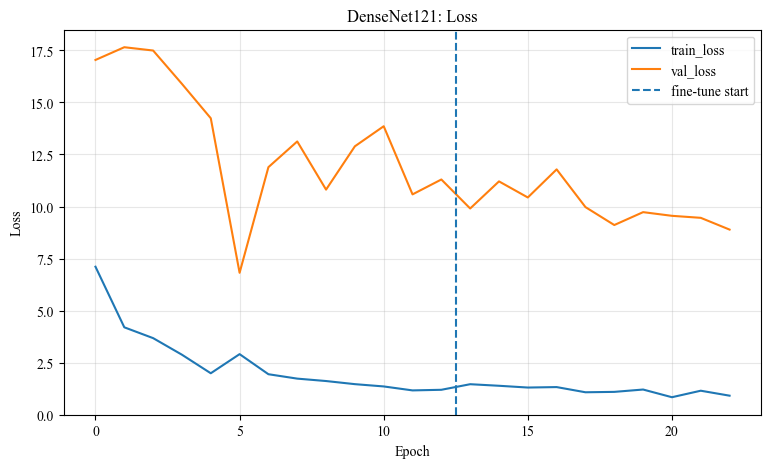

Saved: C:\rsv_experiments\densenet121_20260419_120053\plots\loss_curve.png


In [167]:
plt.figure(figsize=(9, 5))
plt.rc('font',family='Times New Roman')
plt.plot(history_all["loss"], label="train_loss")
plt.plot(history_all["val_loss"], label="val_loss")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("DenseNet121: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "loss_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

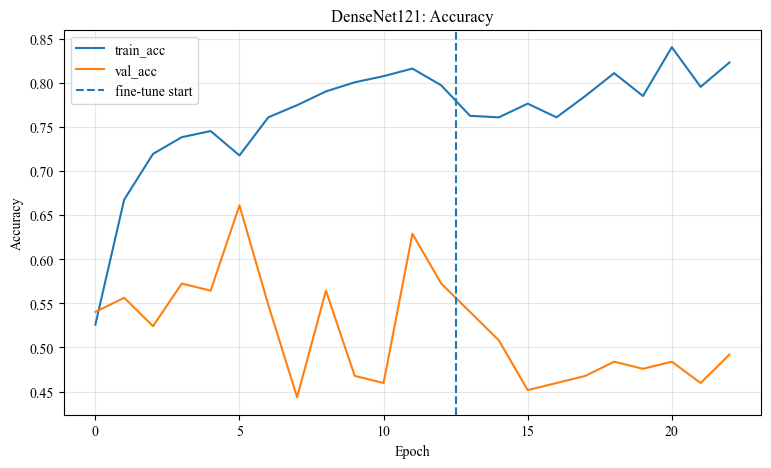

Saved: C:\rsv_experiments\densenet121_20260419_120053\plots\accuracy_curve.png


In [168]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["acc"], label="train_acc")
plt.plot(history_all["val_acc"], label="val_acc")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("DenseNet121: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "accuracy_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

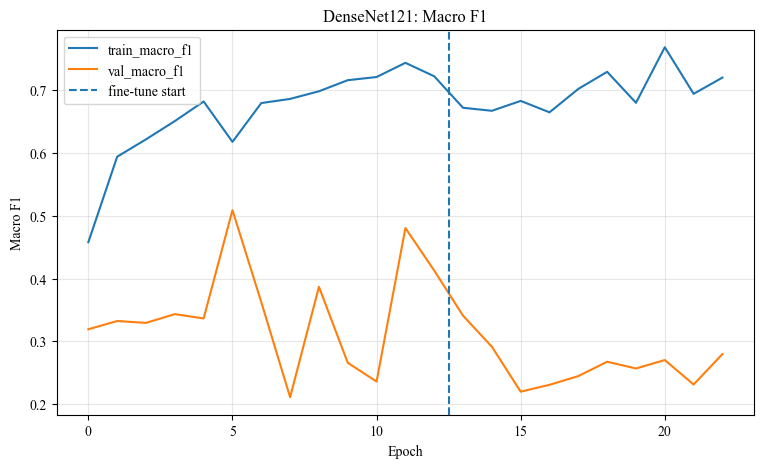

Saved: C:\rsv_experiments\densenet121_20260419_120053\plots\macro_f1_curve.png


In [169]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["macro_f1"], label="train_macro_f1")
plt.plot(history_all["val_macro_f1"], label="val_macro_f1")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("DenseNet121: Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_f1_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

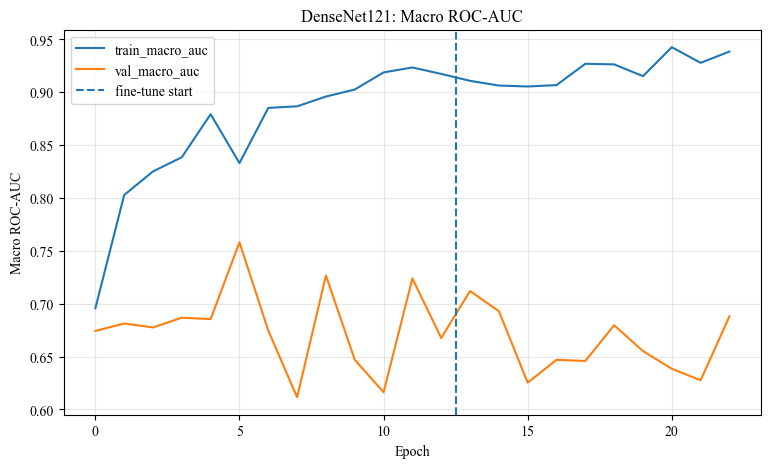

Saved: C:\rsv_experiments\densenet121_20260419_120053\plots\macro_auc_curve.png


In [170]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["macro_auc"], label="train_macro_auc")
plt.plot(history_all["val_macro_auc"], label="val_macro_auc")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("DenseNet121: Macro ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Macro ROC-AUC")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_auc_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [171]:
test_results = model.evaluate(test_ds, return_dict=True)

print("Test results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - acc: 0.5084 - loss: 8.8378 - macro_auc: 0.6512 - macro_f1: 0.2843 - top2_acc: 0.7027
Test results:
acc: 0.5120
loss: 8.6562
macro_auc: 0.6842
macro_f1: 0.3100
top2_acc: 0.7040


In [ ]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().tolist())
    y_prob.extend(probs.tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("y_true:", y_true.shape)
print("y_prob:", y_prob.shape)
print("y_pred:", y_pred.shape)